In [5]:
import numpy as np
import matplotlib.pyplot as plt

fname = "/Users/hongc/Geant4/NewPhysicsAt2x2/Analysis/slope_plot/theta_123.txt"

# ：evt, theta
data = np.loadtxt(fname)
evt   = data[:, 0].astype(int)
theta = data[:, 3]  

print("N events:", len(evt))
print("theta range:", theta.min(), theta.max())

N events: 47
theta range: -1.44477 1.39507


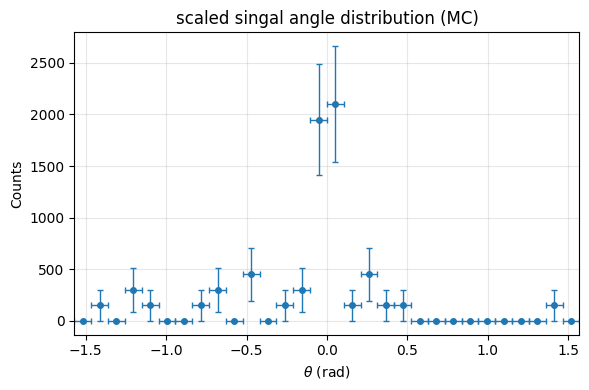

In [25]:
nbins = 30
theta_min = -np.pi/2
theta_max = +np.pi/2

counts, edges = np.histogram(theta, bins=nbins, range=(theta_min, theta_max))
centers = 0.5 * (edges[1:] + edges[:-1])
bin_width = edges[1] - edges[0]

# Poisson errors
scale = 4.5e8/3e6
yerr = np.sqrt(counts)
counts_scaled = counts * scale
err_scaled = yerr * scale
plt.figure(figsize=(6,4))

plt.errorbar(
    centers, counts_scaled,
    yerr=err_scaled,
    xerr=bin_width/2,
    fmt='o',            # points
    markersize=4,      # make points small
    capsize=2,         # little caps on error bars
    elinewidth=1,
    #color='black'
)

plt.xlabel(r"$\theta$ (rad)")
plt.ylabel("Counts")
plt.title("scaled singal angle distribution (MC)")
plt.xlim(theta_min, theta_max)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
from scipy.optimize import curve_fit

def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

In [27]:
A0     = counts.max()
mu0    = centers[np.argmax(counts)]
sigma0 = 0.2   # rad, rough guess

p0 = [A0, mu0, sigma0]

In [33]:
mask = (
    (yerr > 0) &
    (centers >= -0.5) &
    (centers <= 0.5)
)

popt, pcov = curve_fit(
    gauss,
    centers[mask],
    counts_scaled[mask],
    p0=p0,
    sigma=yerr[mask],
    absolute_sigma=True
)

A_fit, mu_fit, sigma_fit = popt
perr = np.sqrt(np.diag(pcov))   # parameter uncertainties

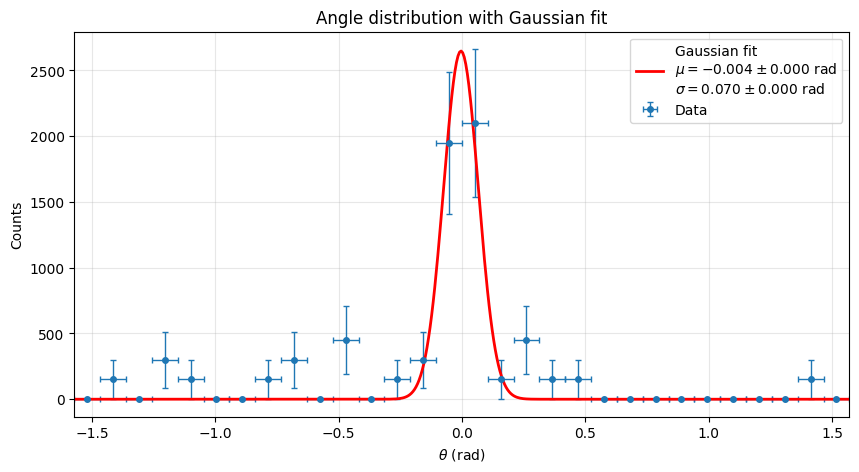

In [34]:
xfit = np.linspace(theta_min, theta_max, 500)
yfit = gauss(xfit, *popt)

plt.figure(figsize=(10,5))

# data with error bars
plt.errorbar(
    centers, counts_scaled,
    yerr=err_scaled,
    xerr=bin_width/2,
    fmt='o',
    markersize=4,
    capsize=2,
    elinewidth=1,
    label="Data"
)

# Gaussian fit curve
plt.plot(xfit, yfit, 'r-', lw=2,
         label=fr"Gaussian fit" "\n"
               fr"$\mu = {mu_fit:.3f} \pm {perr[1]:.3f}$ rad" "\n"
               fr"$\sigma = {sigma_fit:.3f} \pm {perr[2]:.3f}$ rad")

plt.xlabel(r"$\theta$ (rad)")
plt.ylabel("Counts")
plt.title("Angle distribution with Gaussian fit")
plt.xlim(theta_min, theta_max)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [35]:
print(A_fit)
print(mu_fit)
print(sigma_fit)

2647.7216648114527
-0.00384395056035265
0.07045680343088262


In [4]:
print(500*258/30/19)

226.31578947368422


In [15]:
nbins = 3
theta_min = -0.15
theta_max = 0.15

counts, edges = np.histogram(theta, bins=nbins, range=(theta_min, theta_max))

In [16]:
print(counts)

[ 2 23  4]


In [10]:
(3/450)*1.5e19

1e+17

In [11]:
scale = 4.5e8/3e6

In [17]:
30 * scale

4500.0

In [14]:
19127*1.5e19/258000

1.1120348837209303e+18